                    Project : CarbonSense

Week 1 :EDA (Exploratory Data Analysis )

In [ ]:
!pip install codecarbon optuna shap lime dice-ml mapie
!pip install river evidently PyALE lightgbm xgboost scikit-learn
!pip install matplotlib seaborn pandas numpy joblib



#Sustainability : Codecarbon 
#Local Explanation : LIME 
#Actionable AI : DiCE
#Uncertainity : MAPIE
# Real Time Learning : River 
# Monitoring : Evidently 
# Global Explanation : PyALE 


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 67.0 MB/s eta 0:00:00:00:010:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
river 0.24.2 requires numpy<3,>=2.3.4, but you have numpy 2.0.2 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
  Using cached numpy-2.4.4-cp312-cp3

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, joblib

plt.rcParams.update({
    'figure.facecolor': '#07101d',
    'axes.facecolor':   '#04090f',
    'axes.edgecolor':   '#122035',
    'axes.labelcolor':  '#ddeeff',
    'xtick.color':      '#5d88b0',
    'ytick.color':      '#5d88b0',
    'text.color':       '#ddeeff',
    'grid.color':       '#122035',
    'grid.linestyle':   '--',
    'font.family':      'DejaVu Sans',
})
PALETTE = ['#00d4a0','#4d9fff','#f5a623','#ff4d6a','#a78bfa']

#Making Folders :
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('reports', exist_ok=True)



In [3]:
#Download Dataset :
import urllib.request, zipfile , io
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00294/CCPP.zip'
urllib.request.urlretrieve(url,'data/raw/CCPP.zip')
with zipfile.ZipFile('data/raw/CCPP.zip') as z:
    z.extractall('data/raw')


In [4]:
zip_path = 'data/raw/CCPP.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    df = pd.read_excel(z.open('CCPP/Folds5x2_pp.xlsx'))

df.head()

#Target variable is : PE : Energy output 
#CO2= PE*820 so we are predicting CO2 indirectly 

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [5]:
#Track CO2 emmission from Day 1 :
from codecarbon import EmissionsTracker

tr= EmissionsTracker(
    project_name= 'carbonsense_week1_eda',
    output_file= 'reports/emissions_log.csv',
    log_level= 'error'
)

tr.start()
print("Codecarbon tracking is started !!!")

[codecarbon WARNING @ 17:18:42] Multiple instances of codecarbon are allowed to run at the same time.


Codecarbon tracking is started !!!


In [6]:
# Analysing the dataset : excel file
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

print(df.dtypes)

missing = df.isnull().sum()
print(missing )
print(f'Total missing: {missing.sum()} — Dataset is clean ')

df.describe().round(3)

Rows: 9,568 | Columns: 5
AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object
AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64
Total missing: 0 — Dataset is clean 


,AT,V,AP,RH,PE
count,9568.000,9568.000,9568.000,9568.000,9568.000
mean,19.651,54.306,1013.259,73.309,454.365
std,7.452,12.708,5.939,14.600,17.067
min,1.810,25.360,992.890,25.560,420.260
25%,13.510,41.740,1009.100,63.328,439.750
50%,20.345,52.080,1012.940,74.975,451.550
75%,25.720,66.540,1017.260,84.830,468.430
max,37.110,81.560,1033.300,100.160,495.760


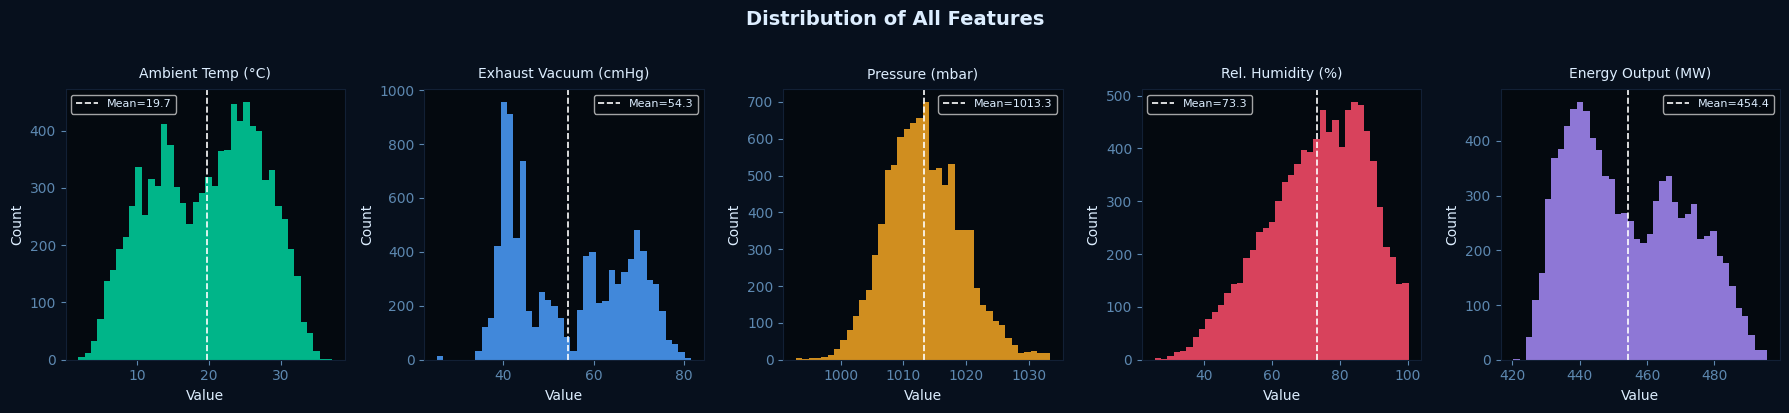

Saved: outputs/plots/01_distributions.png


In [7]:
#Feature distributions :

#Plot 1 : 
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('Distribution of All Features', fontsize=14, fontweight='bold', y=1.02)

col_labels = {
    'AT': 'Ambient Temp (°C)',
    'V':  'Exhaust Vacuum (cmHg)',
    'AP': 'Pressure (mbar)',
    'RH': 'Rel. Humidity (%)',
    'PE': 'Energy Output (MW)'
}

for ax, (col, color) in zip(axes, zip(df.columns, PALETTE)):
    ax.hist(df[col], bins=40, color=color, alpha=0.85, edgecolor='none')
    ax.set_title(col_labels[col], fontsize=10, pad=8)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.axvline(df[col].mean(), color='white', linestyle='--', linewidth=1.2, label=f'Mean={df[col].mean():.1f}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/plots/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/plots/01_distributions.png')

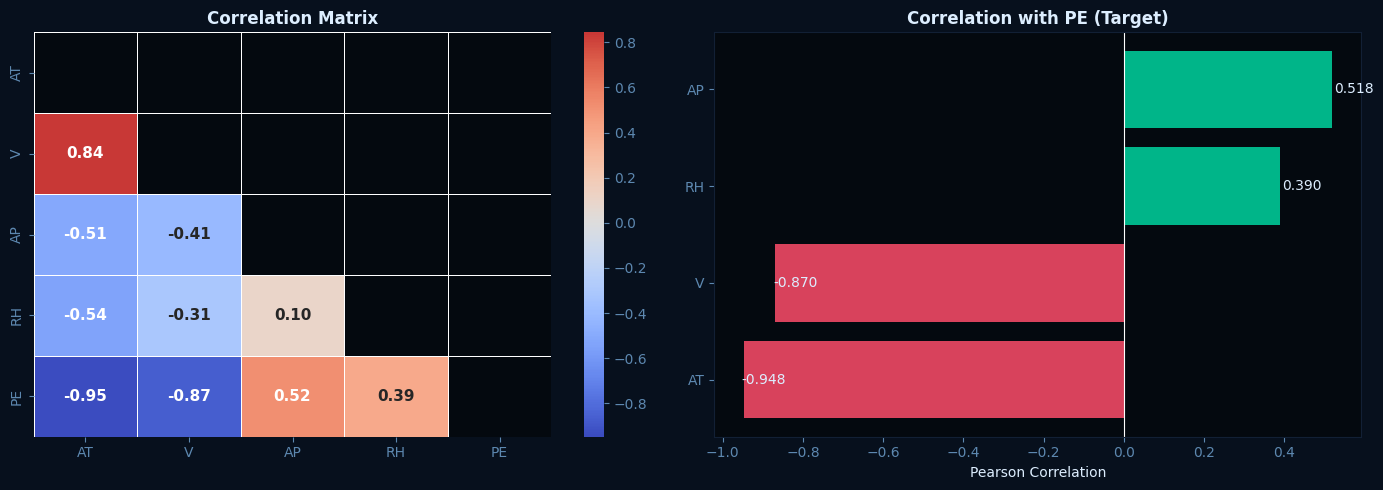

In [8]:
#Plot 2 : Correlation heatmap :
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
axes[0].set_title('Correlation Matrix', fontsize=12, fontweight='bold')

target_corr = corr['PE'].drop('PE').sort_values()
colors = [PALETTE[3] if v < 0 else PALETTE[0] for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values, color=colors, alpha=0.85)
axes[1].axvline(0, color='white', linewidth=0.8)
axes[1].set_title('Correlation with PE (Target)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation')
for i, (v, name) in enumerate(zip(target_corr.values, target_corr.index)):
    axes[1].text(v + 0.005 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=10)


plt.tight_layout()
plt.savefig('outputs/plots/02_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

#Low AT : More CO2
#Low V : More CO2
#High AP : More CO2
#High RP : More CO2


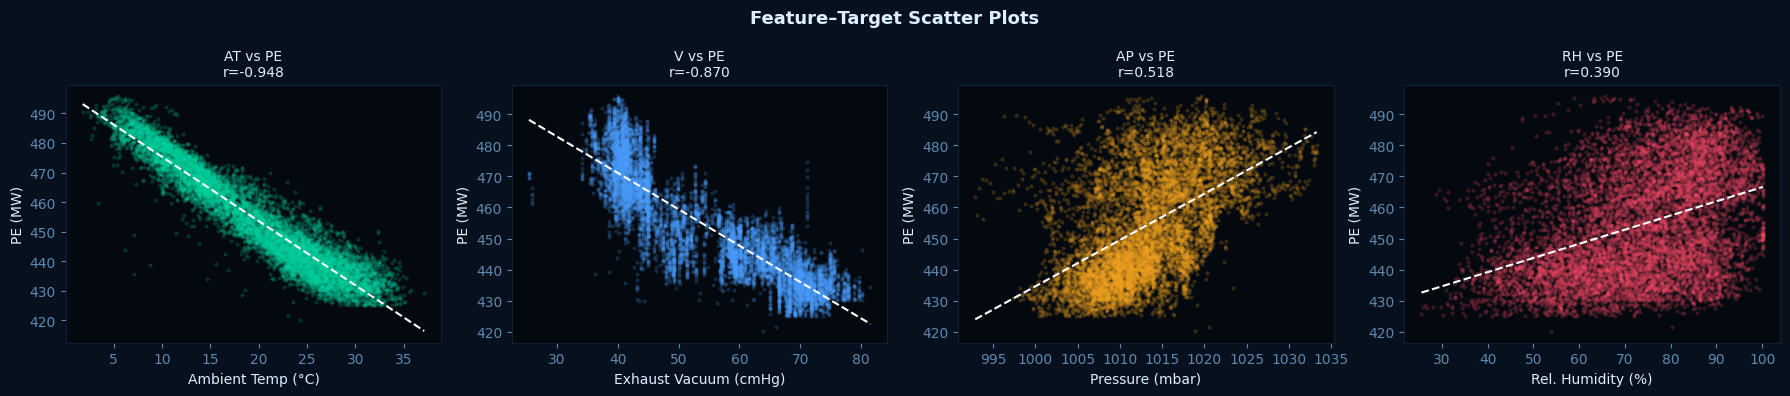

In [9]:
#Plot 3 : Scatter plot :
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
features = ['AT', 'V', 'AP', 'RH']

for ax, feat, color in zip(axes, features, PALETTE):
    ax.scatter(df[feat], df['PE'], alpha=0.15, s=4, color=color)
    # Add trend line
    z = np.polyfit(df[feat], df['PE'], 1)
    p = np.poly1d(z)
    xs = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(xs, p(xs), color='white', linewidth=1.5, linestyle='--')
    ax.set_xlabel(col_labels[feat])
    ax.set_ylabel('PE (MW)')
    ax.set_title(f'{feat} vs PE\nr={df[feat].corr(df["PE"]):.3f}', fontsize=10)

plt.suptitle('Feature–Target Scatter Plots', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/03_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

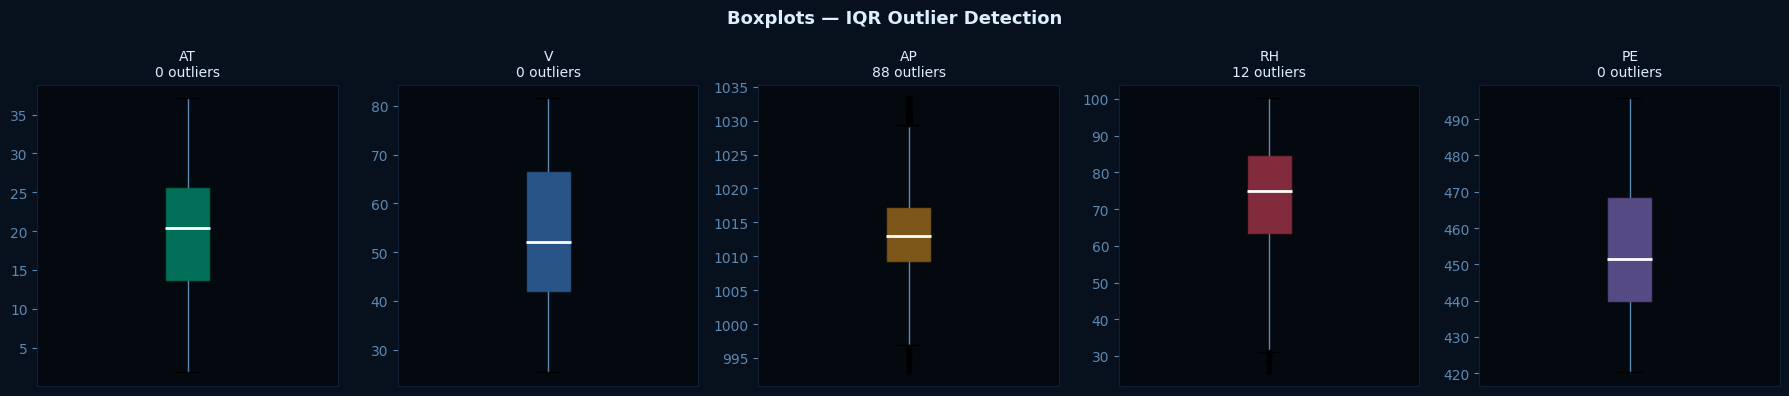

In [10]:
#Detection of Outlier using IQR :

# IQR: Interquartile Range :
#Measures the spread of the middle 50% of the data 
# Divides into Lower bound and Upper Bound 

# Any value below lower bound and above outer bound is being treated as outlier 

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col, color in zip(axes, df.columns, PALETTE):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = df[(df[col] < lo) | (df[col] > hi)][col]
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.5),
               medianprops=dict(color='white', linewidth=2),
               whiskerprops=dict(color='#5d88b0'),
               flierprops=dict(marker='o', color=PALETTE[3], markersize=3))
    ax.set_title(f'{col}\n{len(outliers)} outliers', fontsize=10)
    ax.set_xticks([])

plt.suptitle('Boxplots — IQR Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/04_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
 #Deriving CO2 Target column from energy :
df['co2_kg']= df['PE']*820
print('CO₂ target column created:')
print(df['co2_kg'].describe().round(1))
print(f'\nRange: {df["co2_kg"].min():.0f} – {df["co2_kg"].max():.0f} kg CO₂/hour')

df.to_parquet('data/processed/cleaned_data.parquet', index=False)

eda_emissions = tr.stop()
print(f'\n Week 1 EDA emitted: {eda_emissions*1000:.4f} grams CO₂')




CO₂ target column created:
count      9568.0
mean     372579.3
std       13994.9
min      344613.2
25%      360595.0
50%      370271.0
75%      384112.6
max      406523.2
Name: co2_kg, dtype: float64

Range: 344613 – 406523 kg CO₂/hour

 Week 1 EDA emitted: 0.0267 grams CO₂


Week 2 : Feature Engeneering :


In [12]:
df = pd.read_parquet('data/processed/cleaned_data.parquet')

In [13]:
#Interaction based features :

#Heat Index :
df['heat_index']= df['AT']*df['RH']/100 #High heat_index ,lower CO2 emission 

#Temperature_Vacuum interction :
df['AT_V_ratio']= df['AT']/(df['V']+ 1e-6) # Higher AT_V ratio ,lower CO2 emsission 

#Pressure deviation from normal pressure(1013.25 mbar)
df['AP_deviation']  = df['AP'] - 1013.25

#Cooling efficiency :
df['cooling_eff']   = 1 / (df['AT'] * df['V'] + 1e-6)


In [14]:
#Polynomail based feature :
df['AT_squared'] = df['AT'] ** 2
df['AT_cubed']   = df['AT'] ** 3
df['RH_log'] = np.log1p(df['RH'])




In [15]:
#Binning based features :
#Created only for clustering as we will train models on real actual data 
df['AT_bin'] = pd.cut(df['AT'],
    bins=[-np.inf, 10, 18, 26, np.inf],
    labels=['cold', 'mild', 'warm', 'hot'])

df['load_mode'] = pd.cut(df['PE'],
    bins=4,
    labels=['idle', 'low_load', 'med_load', 'peak_load'])


In [16]:
#Statistical Rolling based features :
#Rolling_mean : What is the average temperature around this point 
#Rolling std : How much does temperature fluctuate around this point 

# In real IoT data : Previous readings matter :
df_sorted = df.sort_values('AT').reset_index(drop=True)

for x in [50, 100, 200]:
    df_sorted[f'AT_roll_mean_{x}'] = df_sorted['AT'].rolling(x, min_periods=1).mean()
    df_sorted[f'AT_roll_std_{x}']  = df_sorted['AT'].rolling(x, min_periods=1).std().fillna(0)


df = df_sorted.copy()




In [17]:
#Missing values Indicators : if any present 
base_features = ['AT', 'V', 'AP', 'RH']
for col in base_features:
    df[f'{col}_missing'] = df[col].isnull().astype(int)

print('Missing indicators added (all zeros since dataset is clean).')
print(f'Total features now: {df.shape[1]}')
print(df.describe().round(3))



Missing indicators added (all zeros since dataset is clean).
Total features now: 25
             AT         V        AP        RH        PE      co2_kg  \
count  9568.000  9568.000  9568.000  9568.000  9568.000    9568.000   
mean     19.651    54.306  1013.259    73.309   454.365  372579.308   
std       7.452    12.708     5.939    14.600    17.067   13994.936   
min       1.810    25.360   992.890    25.560   420.260  344613.200   
25%      13.510    41.740  1009.100    63.328   439.750  360595.000   
50%      20.345    52.080  1012.940    74.975   451.550  370271.000   
75%      25.720    66.540  1017.260    84.830   468.430  384112.600   
max      37.110    81.560  1033.300   100.160   495.760  406523.200   

       heat_index  AT_V_ratio  AP_deviation  cooling_eff  ...  \
count    9568.000    9568.000      9568.000     9568.000  ...   
mean       13.816       0.354         0.009        0.001  ...   
std         4.738       0.090         5.939        0.001  ...   
min         1.39

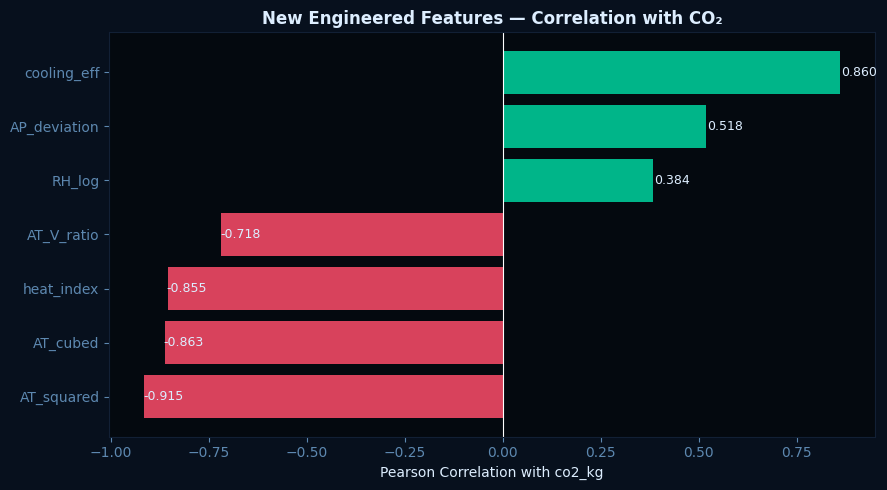

In [18]:
#Plotting new features correlation with CO2 Target :
new_feats = ['heat_index', 'AT_V_ratio', 'AP_deviation', 'cooling_eff',
             'AT_squared', 'AT_cubed', 'RH_log']

corr_new = df[new_feats + ['co2_kg']].corr()['co2_kg'].drop('co2_kg').sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PALETTE[3] if v < 0 else PALETTE[0] for v in corr_new.values]
ax.barh(corr_new.index, corr_new.values, color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title('New Engineered Features — Correlation with CO₂', fontsize=12, fontweight='bold')
ax.set_xlabel('Pearson Correlation with co2_kg')
for i, v in enumerate(corr_new.values):
    ax.text(v + 0.003 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('outputs/plots/05_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

Temperature-based features
 Low AT² →  High CO₂
 High AT² →  Low CO₂
 Low AT³ →  High CO₂
 High AT³ →  Low CO₂

 Heat interaction
 High Heat Index →  Low CO₂
 Low Heat Index →  High CO₂

 Temperature–Vacuum interaction
 High AT_V_ratio →  Low CO₂
 Low AT_V_ratio →  High CO₂

 Pressure behavior
 High AP_deviation →  Higher CO₂
 Low AP_deviation →  Lower CO₂

 Humidity effect (log transformed)
 High RH_log →  Slightly higher CO₂
 Low RH_log →  Slightly lower CO₂

 Cooling efficiency
 High cooling_eff →  High CO₂
 Low cooling_eff →  Low CO₂

 

In [19]:
#saving feature -engineered dataset :
df_ml = df.drop(columns=['AT_bin','load_mode']).copy()
df_ml.to_parquet('data/processed/featured_engineered.parquet',index=False)

Week 3 : Baseline +Advanced Modelling 


In [20]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

df_ml= pd.read_parquet('data/processed/featured_engineered.parquet')

target= 'co2_kg'
drop_cols= ['PE','co2_kg']
features= [x for x in df_ml.columns if x not in drop_cols]

X= df_ml[features]
y= df_ml[target]

In [21]:
#Train -Test -Split :
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42)


In [22]:
def evaluate_model(name,model,X_t,y_t):
    pred = model.predict(X_t)
    rmse = np.sqrt(mean_squared_error(y_t, pred))
    mae  = mean_absolute_error(y_t, pred)
    r2   = r2_score(y_t, pred)    
    return {'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'predictions': pred}

results= {}

In [23]:
#Model 1 : Ridge Regression :

ridge_pipe= Pipeline([
    ('scaler',StandardScaler()),
    ('model',Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train,y_train)
results['Ridge']= evaluate_model('Ridge Regression',ridge_pipe,X_test,y_test)

In [24]:
#Model 2 : Elasticnet : L1 +L2 regualarization 
en_pipe= Pipeline([
    ('scaler',StandardScaler()),
    ('model',ElasticNet(alpha=0.1,l1_ratio=0.5,max_iter=5000))
])
en_pipe.fit(X_train, y_train)
results['ElasticNet'] = evaluate_model('Elastic Net', en_pipe, X_test, y_test)


In [25]:
#Model 3 : Random forest 
rf = RandomForestRegressor(
    n_estimators=200, max_depth=12,
    min_samples_leaf=3, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)
results['RandomForest'] = evaluate_model('Random Forest', rf, X_test, y_test)

In [26]:
#Model 4 : XGBoost
#Now comes the real Industry scenario instead of assumptions 

# Hot air = less dense air
#Less dense air → less oxygen intake
#Less oxygen → combustion efficiency drops
#Efficiency drops → plant must burn more fuel
#More fuel → more CO₂ emissions

#So:
#   AT  (+1): Hotter ambient → more cooling needed → more CO₂
#   V   (-1): Higher vacuum → more efficient turbine → less CO₂
#   AP  ( 0): Pressure has complex, non-monotone effect
#   RH  (+1): Higher humidity → lower efficiency → more CO₂

monotone_map = {'AT':1,"V":-1,"AP":0,"RH":1}
constraints_list= [monotone_map.get(x,0) for x in features]
constraints_str = "(" + ",".join(map(str, constraints_list)) + ")"

xgb = XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    monotone_constraints=constraints_str,  # ← PHYSICS BAKED IN
    tree_method='hist',
    random_state=42,
    verbosity=0)

#While training keep check on unseen val data 
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

results['XGBoost'] = evaluate_model('XGBoost (monotone)', xgb, X_test, y_test)

constrained= {features[i]: v for i, v in enumerate(constraints_list) if v!=0}
for feat,direction in constrained.items():
     symbol = '↑ (must increase CO₂)' if direction == 1 else '↓ (must decrease CO₂)'
     print(f'  {feat}: {symbol}')
    




  AT: ↑ (must increase CO₂)
  V: ↓ (must decrease CO₂)
  RH: ↑ (must increase CO₂)


In [27]:
#Model 5 :LightBGM 
lgbm = LGBMRegressor(
      n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    random_state=42,
    verbose=-1
    
)
lgbm.fit(X_train,y_train)
results['LightGBM']= evaluate_model('LightGBM',lgbm,X_test,y_test)

In [28]:
#Optuna Tuning on XGBoost:
def xgb_optuna(trial):
     params = {
        'n_estimators':    trial.suggest_int('n_estimators', 200, 800),
        'max_depth':       trial.suggest_int('max_depth', 3, 9),
        'learning_rate':   trial.suggest_float('lr', 0.01, 0.2, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':trial.suggest_float('colsample', 0.6, 1.0),
        'reg_alpha':       trial.suggest_float('alpha', 1e-4, 10, log=True),
        'reg_lambda':      trial.suggest_float('lambda', 1e-4, 10, log=True),
     }
     m= XGBRegressor(**params, monotone_constraints=constraints_str,
                     tree_method='hist', random_state=42, verbosity=0)
     m.fit(X_train, y_train)
     pred = m.predict(X_val)
     return np.sqrt(mean_squared_error(y_val, pred))

#Note : Direction (minimize ): rmse,mse etc 
#Direction (maximize ):roc_auc,pr_auc etc 
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_optuna, n_trials=40, show_progress_bar=True)

best_params= study_xgb.best_params

print(f'\nBest RMSE (val): {study_xgb.best_value:.2f}')
print(f'Best params: {best_params}')



    

  0%|          | 0/40 [00:00<?, ?it/s]


Best RMSE (val): 3157.16
Best params: {'n_estimators': 483, 'max_depth': 8, 'lr': 0.014543321159213356, 'subsample': 0.6231371667125606, 'colsample': 0.8986952528551438, 'alpha': 0.0006574196110222762, 'lambda': 4.555559197085532}


In [29]:
np.mean(y_test)

np.float64(372750.18474399165)

In [30]:
#Train_Tuned_XGBoost :
xgb_tuned = XGBRegressor(
    **best_params,
    monotone_constraints=constraints_str,
    tree_method='hist', random_state=42, verbosity=0
)
xgb_tuned.fit(X_train, y_train)
results['XGB_Tuned'] = evaluate_model('XGBoost Tuned', xgb_tuned, X_test, y_test)


In [31]:
#Note that sklearn assumes higher value: Better model 
#But lower the RMSE better the model is so we do its negative 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    xgb_tuned, X, y, cv=kf,
    scoring='neg_root_mean_squared_error', n_jobs=-1)

print(' 5-Fold Cross Validation (XGBoost Tuned) ')
print(f'RMSE per fold: {(-cv_scores).round(2)}')
print(f'Mean RMSE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}')


 5-Fold Cross Validation (XGBoost Tuned) 
RMSE per fold: [3290.94 3149.6  3243.32 3304.79 3315.  ]
Mean RMSE: 3260.73 ± 60.75


       Model        RMSE         MAE       R²
    LightGBM 2805.211468 2096.280506 0.959948
RandomForest 2991.178806 2236.147451 0.954461
     XGBoost 3119.914603 2355.494599 0.950457
   XGB_Tuned 3369.702886 2536.269919 0.942207
       Ridge 3563.533294 2823.072374 0.935367
  ElasticNet 3657.207463 2914.328938 0.931924


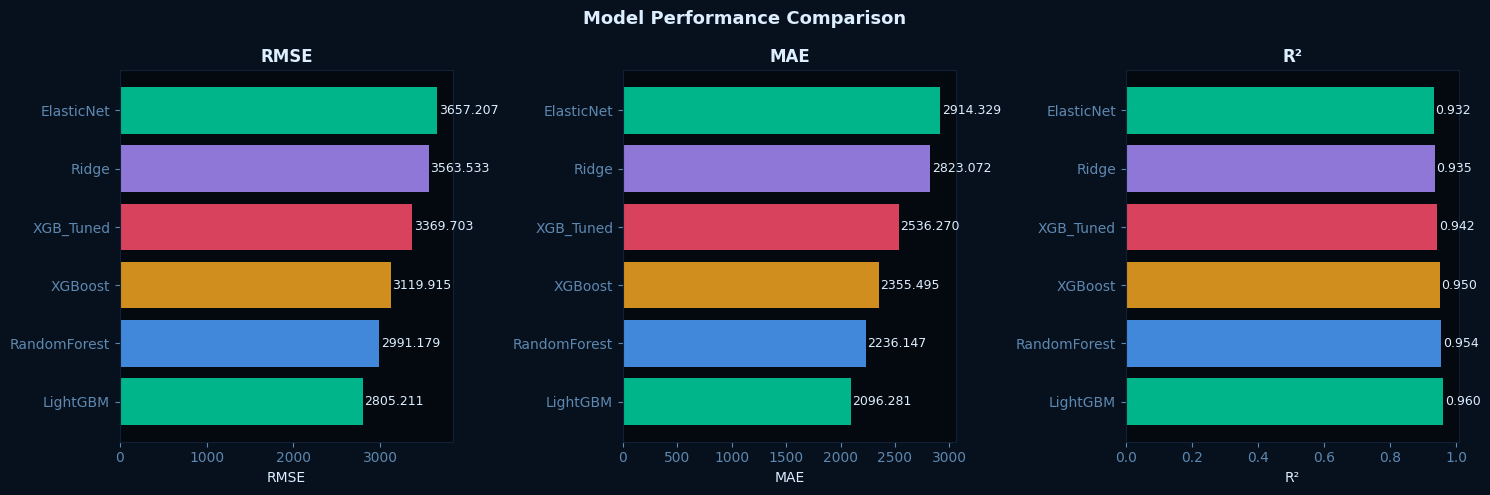

In [32]:
#Model Comparison :
comparison_df = pd.DataFrame([
    {'Model': k, 'RMSE': v['rmse'], 'MAE': v['mae'], 'R²': v['r2']}
    for k, v in results.items()
]).sort_values('RMSE').reset_index(drop=True)

print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['RMSE', 'MAE', 'R²']
palette_bar = PALETTE[:len(comparison_df)]

for ax, metric in zip(axes, metrics):
    data = comparison_df.sort_values(metric, ascending=(metric != 'R²'))
    bars = ax.barh(data['Model'], data[metric],
                   color=PALETTE[:len(data)], alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#Shows best = LightBGM 


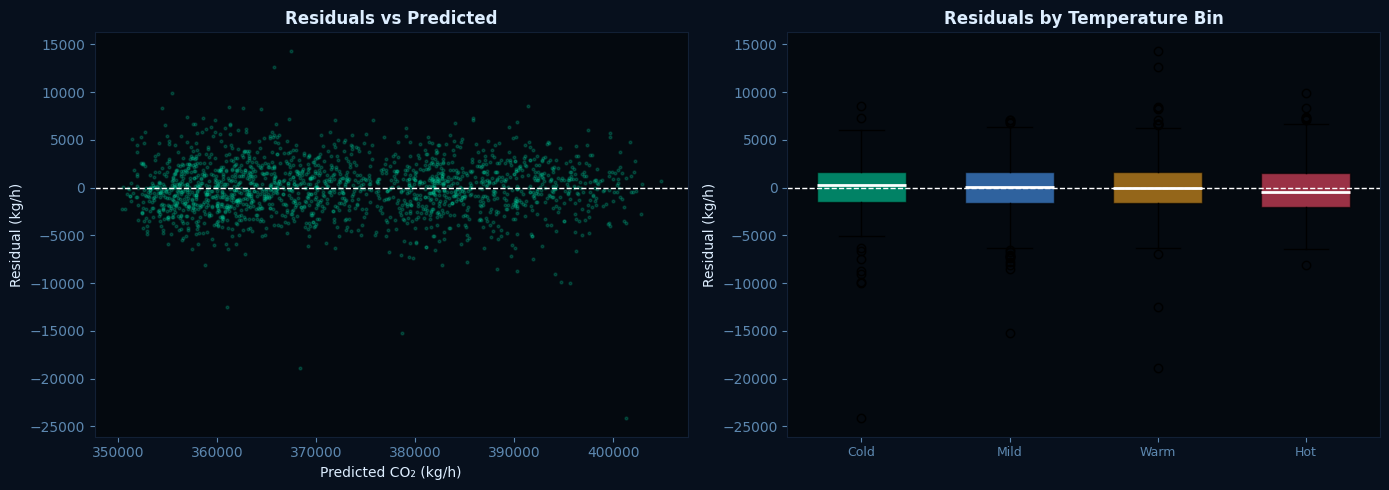

Residuals are symmetric → no systematic bias ✅


In [33]:
#Residual Analysis :
#Residual : Actual- Predicted 
# To understand where and how the model is making mistakes 
#Error per data point 
#Positive-> Underpredicting 
#Negative->Overpredicting 

Best_model= lgbm 
residuals= y_test-results['LightGBM']['predictions']
X_test_copy= X_test.copy()
X_test_copy['residual']=residuals
X_test_copy['AT_bin'] = pd.cut(X_test_copy['AT'],
    bins=[-np.inf, 10, 18, 26, np.inf],
    labels=['Cold (<10°C)', 'Mild (10–18°C)', 'Warm (18–26°C)', 'Hot (>26°C)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual vs predicted
axes[0].scatter(results['XGB_Tuned']['predictions'], residuals,
               alpha=0.2, s=4, color=PALETTE[0])
axes[0].axhline(0, color='white', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted CO₂ (kg/h)')
axes[0].set_ylabel('Residual (kg/h)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

# Residuals by temperature bin
for i, (bin_name, group) in enumerate(X_test_copy.groupby('AT_bin', observed=True)):
    axes[1].boxplot(group['residual'],
                   positions=[i], widths=0.6,
                   patch_artist=True,
                   boxprops=dict(facecolor=PALETTE[i], alpha=0.6),
                   medianprops=dict(color='white', linewidth=2))

axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['Cold', 'Mild', 'Warm', 'Hot'], fontsize=9)
axes[1].axhline(0, color='white', linestyle='--', linewidth=1)
axes[1].set_ylabel('Residual (kg/h)')
axes[1].set_title('Residuals by Temperature Bin', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/07_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Residuals are symmetric → no systematic bias ✅')



In [34]:
joblib.dump(Best_model,  'models/best_lgbm_model.pkl')
joblib.dump(X_train.columns.tolist(), 'models/feature_names.pkl')

['models/feature_names.pkl']

In [35]:
!pip install --upgrade numba
import shap 
from sklearn.inspection import PartialDependenceDisplay

Best_model= joblib.load('models/best_lgbm_model.pkl')
Feature_Names= joblib.load('models/feature_names.pkl')




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 70.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: numba
    Found existing installation: numba 0.60.0
    Uninstalling numba-0.60.0:
      Successfully uninstalled numba-0.60.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0

In [36]:
#SHAP : Explainable AI:
#Global Tree Explainer"
explainer= shap.TreeExplainer(Best_model)
shap_values= explainer(X_test)
print(f'SHAP values shape: {shap_values.values.shape}')

SHAP values shape: (1914, 21)


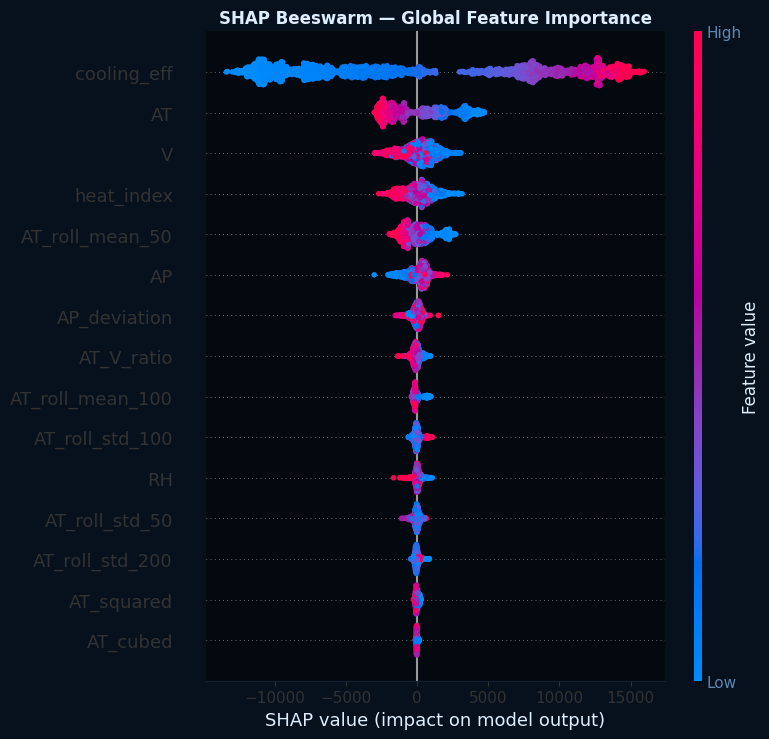

In [37]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    plot_type='dot',    # beeswarm
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm — Global Feature Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/08_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

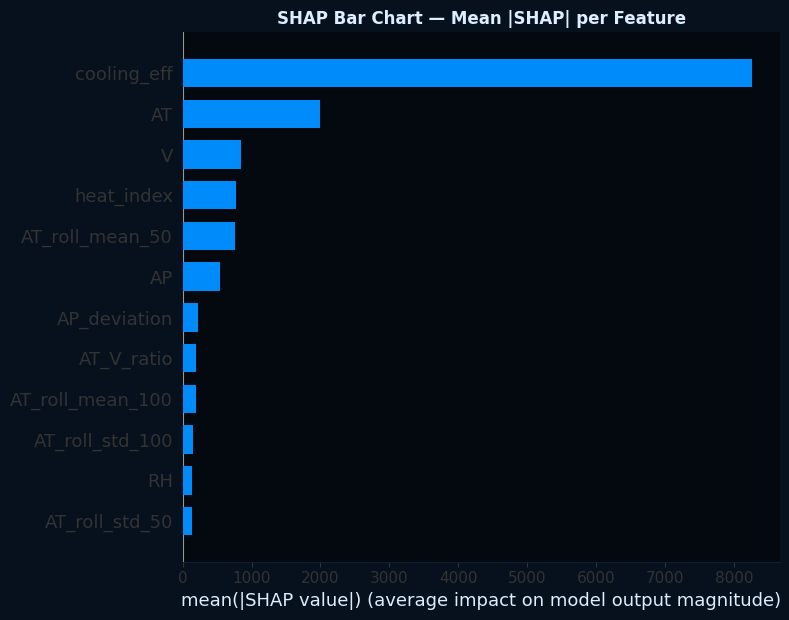

In [38]:
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=12,
    show=False
)
plt.title('SHAP Bar Chart — Mean |SHAP| per Feature', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/09_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

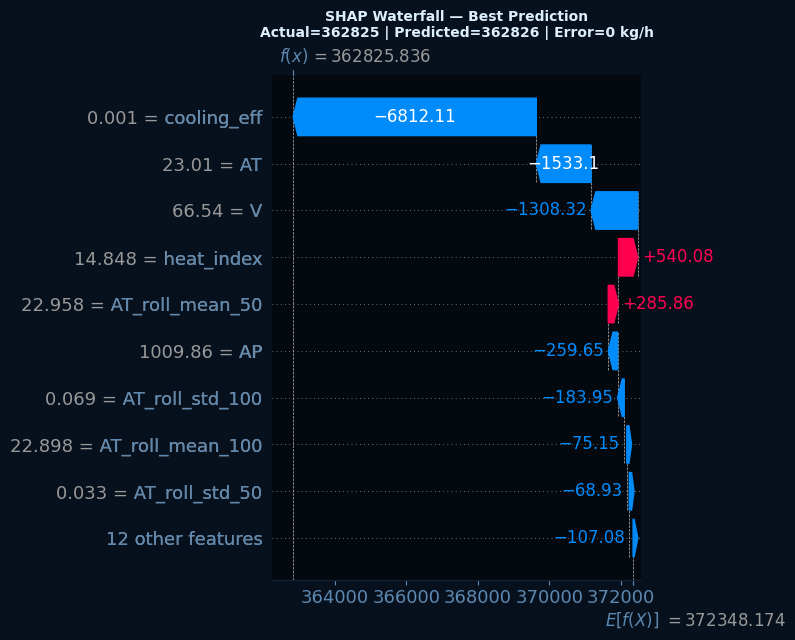

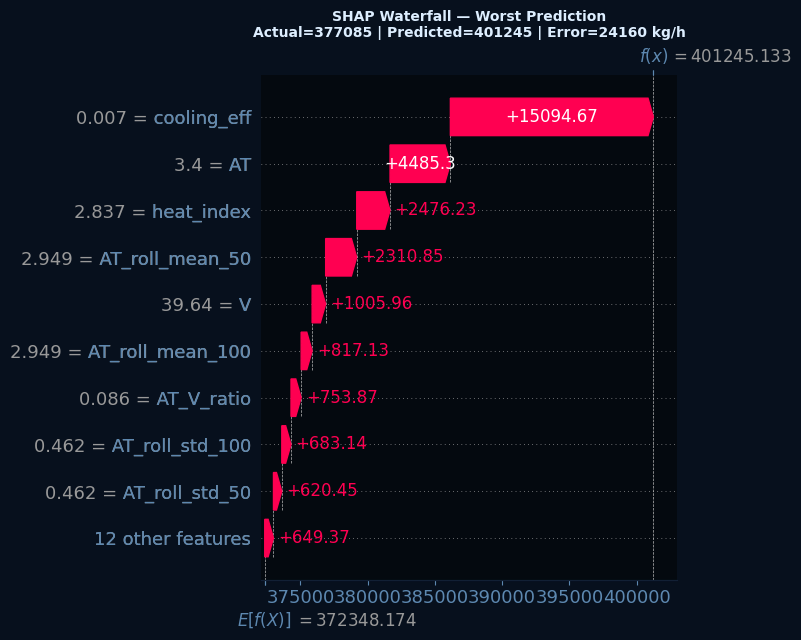

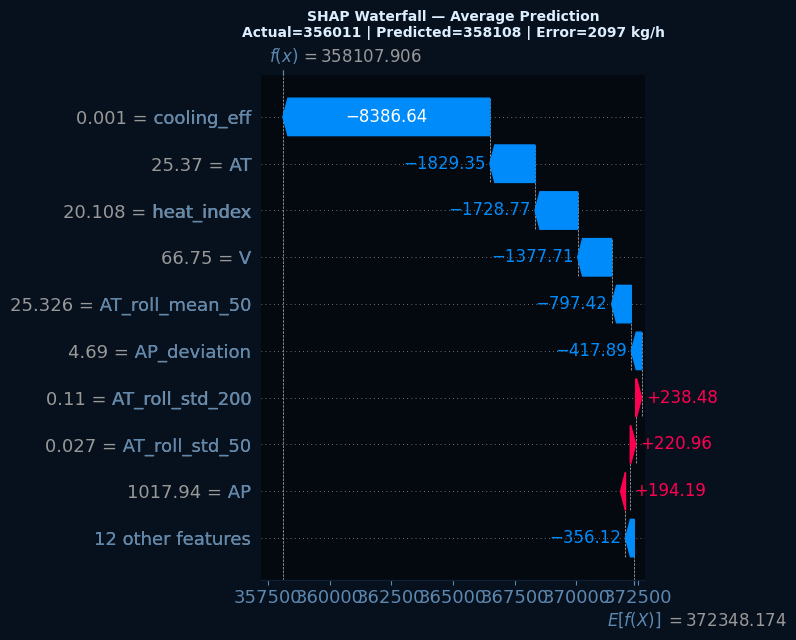

In [39]:
#Explaining 3 individual predictions :
#Best prediction 
#Worst prediction 
#Average prediction 

preds      = Best_model.predict(X_test)
errors     = np.abs(preds - y_test.values)
idx_best   = errors.argmin()
idx_worst  = errors.argmax()
idx_mid    = np.abs(errors - errors.mean()).argmin()

for idx, label in [(idx_best, 'Best Prediction'),
                   (idx_worst, 'Worst Prediction'),
                   (idx_mid, 'Average Prediction')]:
    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f'SHAP Waterfall — {label}\n'
              f'Actual={y_test.values[idx]:.0f} | '
              f'Predicted={preds[idx]:.0f} | '
              f'Error={errors[idx]:.0f} kg/h',
              fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'outputs/plots/10_waterfall_{label.split()[0].lower()}.png',
                dpi=150, bbox_inches='tight')
    plt.show()



<Figure size 900x500 with 0 Axes>

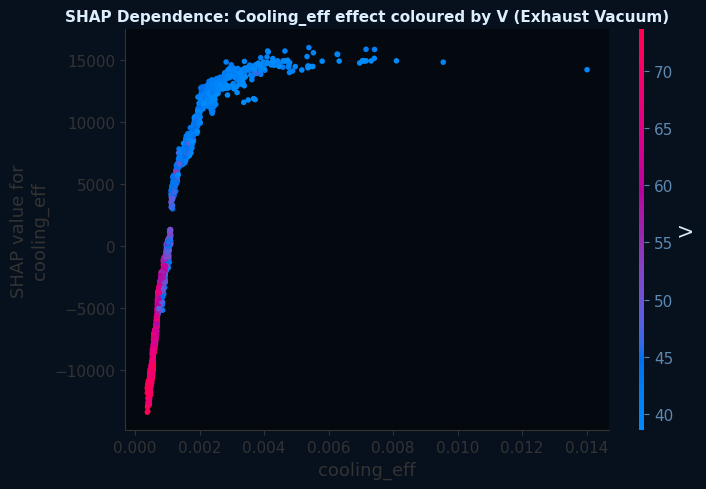

In [40]:
#Dependance plot : Shows how cooling_eff affects the prediction and interaction with V 
plt.figure(figsize=(9, 5))
shap.dependence_plot(
    'cooling_eff', shap_values.values, X_test,
    interaction_index='V',   # colour by exhaust vacuum
    show=False
)
plt.title('SHAP Dependence: Cooling_eff effect coloured by V (Exhaust Vacuum)',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/11_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

#Vacuum moderates the effect of cooling efficiency: when vacuum is low, cooling efficiency has a stronger impact on CO₂; when vacuum is high, its impact is reduced.


In [41]:
#LIME uses training data 
#SHAP uses test data

#LIME:Local Interpretable Model-Agnostic Explanations 
# LIME explains one prediction by approximating the model locally with a simple model 

#Like why does model predict high CO2 for thhis specific case 

#Note:
#LIME store training data statistics 
#Uses them in test data 

# LIME local model is trained on your models behaviour 

#Training Data (X_train)
 #  ↓
#Initialize LIME (learn distribution)
   #↓
#Pick test sample (X_test[idx])
#   ↓
#Generate nearby fake samples
 #  ↓
#Pass them to BEST_MODEL.predict
#   ↓
#Get predictions
#   ↓
#Fit simple local model
  # ↓
#Extract feature importance
#   ↓
#Print explanation


import lime 
import lime.lime_tabular 

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names= features,
    mode='regression',
    random_state=42
    
)

sample_indices= [idx_best,idx_worst,idx_mid]
sample_labels=['Best', 'Worst', 'Average']

for idx, label in zip(sample_indices, sample_labels):
    lime_exp = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        Best_model.predict,
        num_features=6
    )
    
    print(lime_exp.as_list())






[('0.00 < cooling_eff <= 0.00', -6220.507013107485), ('20.61 < AT <= 25.86', -2308.7312986772035), ('20.55 < AT_roll_mean_50 <= 25.79', -818.4507667975375), ('8748.18 < AT_cubed <= 17293.61', -419.5088960466381), ('0.30 < AT_V_ratio <= 0.36', -371.4433586550058), ('63.34 < RH <= 74.84', 333.45342358902093)]
[('cooling_eff > 0.00', 13102.21937973434), ('AT <= 13.56', 3992.8840626803226), ('AT_roll_mean_50 <= 13.51', 1829.0482541071383), ('heat_index <= 10.31', 1593.6799286218943), ('V <= 41.79', 976.9631469432405), ('AT_roll_std_50 > 0.05', -901.6864625283348)]
[('0.00 < cooling_eff <= 0.00', -6673.948383729), ('heat_index > 17.60', -1631.575902975925), ('20.61 < AT <= 25.86', -1557.6791574153165), ('V > 66.54', -972.993789729992), ('AP > 1017.17', 663.22264901301), ('20.55 < AT_roll_mean_50 <= 25.79', -627.331795282629)]


  LIME top features: ['0.00', 'heat_index', '20.61']
  SHAP top features: ['cooling_eff', 'AT', 'heat_index']


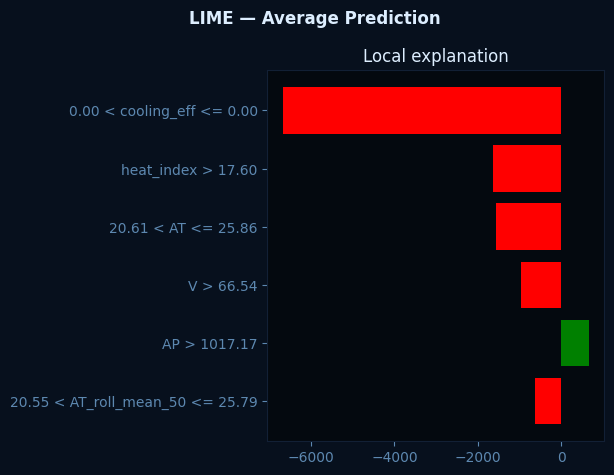

In [42]:

lime_features = {
    k.split(' ')[0].split('<')[0].split('>')[0].strip(): abs(v)
    for k, v in lime_exp.as_list()
}


shap_top6 = pd.Series(
    np.abs(shap_values.values[idx]),
    index=Feature_Names
).nlargest(6)

print(f'  LIME top features: {list(lime_features.keys())[:3]}')
print(f'  SHAP top features: {list(shap_top6.index)[:3]}')


fig = lime_exp.as_pyplot_figure()
fig.suptitle(f'LIME — {label} Prediction', fontweight='bold')

plt.tight_layout()
plt.savefig(
    f'outputs/plots/12_lime_{label.lower()}.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

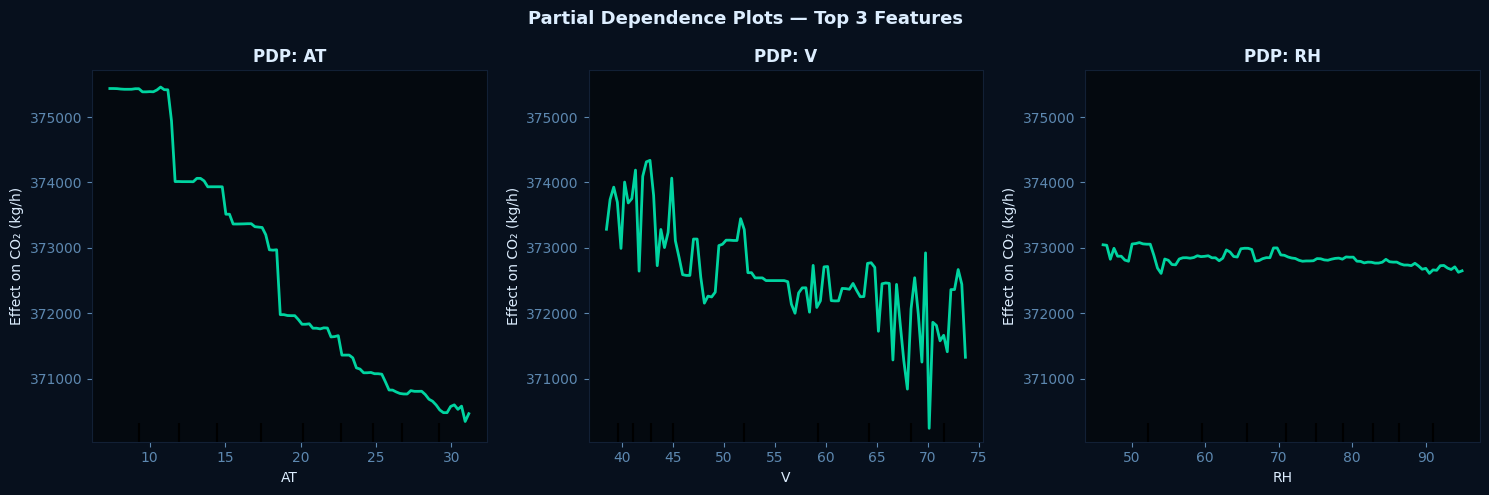

In [43]:
#Partial_Dependancy_Plots :
#How each feature individually affects CO2 productions:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
top_features_pdp = ['AT', 'V', 'RH']  

PartialDependenceDisplay.from_estimator(
    Best_model, X_test, top_features_pdp,
    ax=axes, line_kw={'color': PALETTE[0], 'linewidth': 2}
)

for ax, feat in zip(axes, top_features_pdp):
    ax.set_title(f'PDP: {feat}', fontweight='bold')
    ax.set_ylabel('Effect on CO₂ (kg/h)')

plt.suptitle('Partial Dependence Plots — Top 3 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/13_pdp.png', dpi=150, bbox_inches='tight')
plt.show()


PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.
PyALE._ALE_generic:INFO: Continuous feature detected.


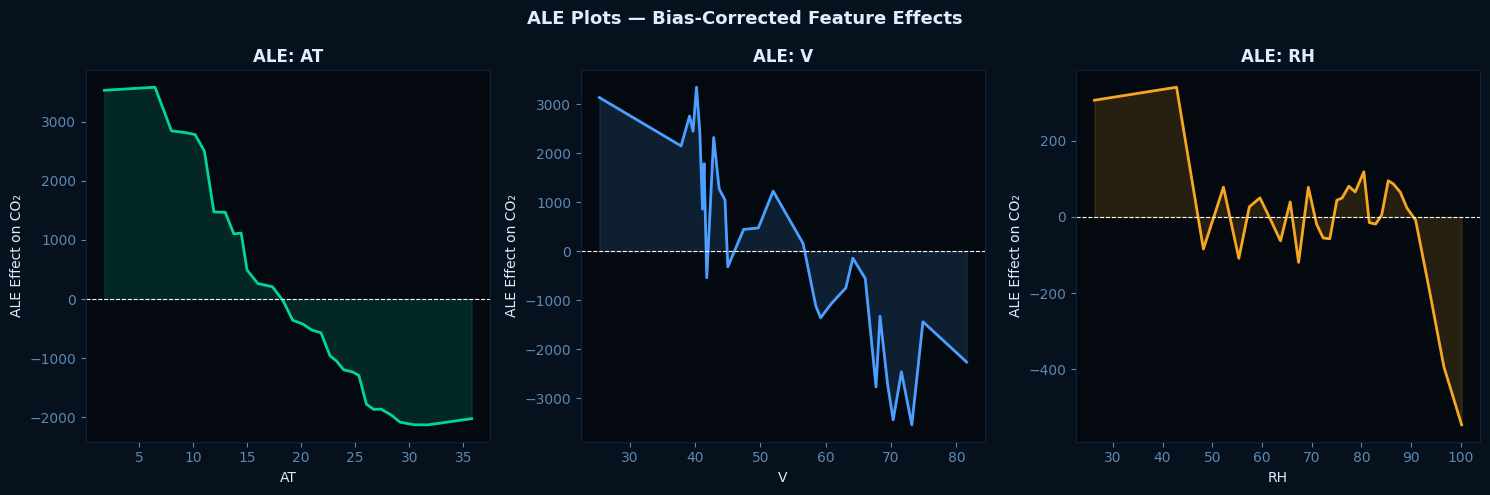

In [44]:
#ALE: Accumulated Local Effects :
#How each feature affects CO2 while correctly handling feature correlations : 

#More reliable than PDP

try :
    from PyALE import ale
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, feat, color in zip(axes, top_features_pdp, PALETTE[:3]):
        ale_eff = ale(
            X=X_test.reset_index(drop=True),#reset_index= to properly align the index 
            model=Best_model,
            feature=[feat],
            grid_size=30,
            plot=False
        )
        ax.plot(ale_eff.index, ale_eff.iloc[:, 0], color=color, linewidth=2)
        ax.axhline(0, color='white', linestyle='--', linewidth=0.8)
        ax.fill_between(ale_eff.index, ale_eff.iloc[:, 0], 0,
                        alpha=0.15, color=color)
        ax.set_title(f'ALE: {feat}', fontweight='bold')
        ax.set_xlabel(feat)
        ax.set_ylabel('ALE Effect on CO₂')

    plt.suptitle('ALE Plots — Bias-Corrected Feature Effects', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/plots/14_ale.png', dpi=150, bbox_inches='tight')
    plt.show()

except ImportError:
    print("It is not installed correctly or version not supported ")
    

In [45]:
!pip uninstall mapie -y
!pip install mapie==0.6.0

import mapie
print(mapie.__version__)

import mapie.regression
print(dir(mapie.regression))

Found existing installation: MAPIE 1.4.0
Uninstalling MAPIE-1.4.0:
  Successfully uninstalled MAPIE-1.4.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 4.2 MB/s eta 0:00:00
0.6.0
['ArrayLike', 'BaseCrossValidator', 'BaseEstimator', 'ConformityScore', 'Iterable', 'LinearRegression', 'List', 'MapieRegressor', 'NDArray', 'Optional', 'Parallel', 'Pipeline', 'RegressorMixin', 'Tuple', 'Union', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', '_check_y', '_num_samples', '_safe_indexing', 'aggregate_all', 'annotations', 'cast', 'check_alpha', 'check_alpha_and_n_samples', 'check_conformity_score', 'check_cv', 'check_estimator_fit_predict', 'check_is_fitted', 'check_n_features_in', 'check_n_jobs', 'check_nan_in_aposteriori_prediction', 'check_null_weight', 'check_verbose', 'clone', 'delayed', 'fit_estimator', 'indexable', 'np', 'np_nanquantile', 'phi2D']


Week 5 : Counterfactuals and Conformal Predictions 


In [46]:
#MAPIE: used to quantify uncertainity in machine learning predictions 
#How sure my model is aboout its prediction 

#DICE: what should i change in my input to get a different prediction 
#Part of Explainable AI 

from mapie.regression import MapieRegressor

mapie = MapieRegressor(
    estimator=Best_model,
    method='plus',   # jackknife+ — more accurate intervals
    cv=5             # 5-fold cross-conformal
)
mapie.fit(X_train, y_train)


y_pred_mapie, y_pis = mapie.predict(X_test, alpha=0.10)
lower = y_pis[:, 0, 0]
upper = y_pis[:, 1, 0]

covered = ((y_test.values >= lower) & (y_test.values <= upper)).mean()
avg_width = (upper - lower).mean()


print(f'Empirical coverage: {covered*100:.1f}% ')
print(f'Average interval width: ±{avg_width/2:.1f} kg/h')
print(f'\nExample prediction:')
i = 0
print(f'  Predicted: {y_pred_mapie[i]:.0f} kg/h')
print(f'  Interval:  [{lower[i]:.0f}, {upper[i]:.0f}] kg/h (90% confident)')
print(f'  Actual:    {y_test.values[i]:.0f} kg/h')

#90.6% so this conforms the conformal guarentee is working 


Empirical coverage: 90.9% 
Average interval width: ±4633.1 kg/h

Example prediction:
  Predicted: 382254 kg/h
  Interval:  [377840, 386933] kg/h (90% confident)
  Actual:    379562 kg/h


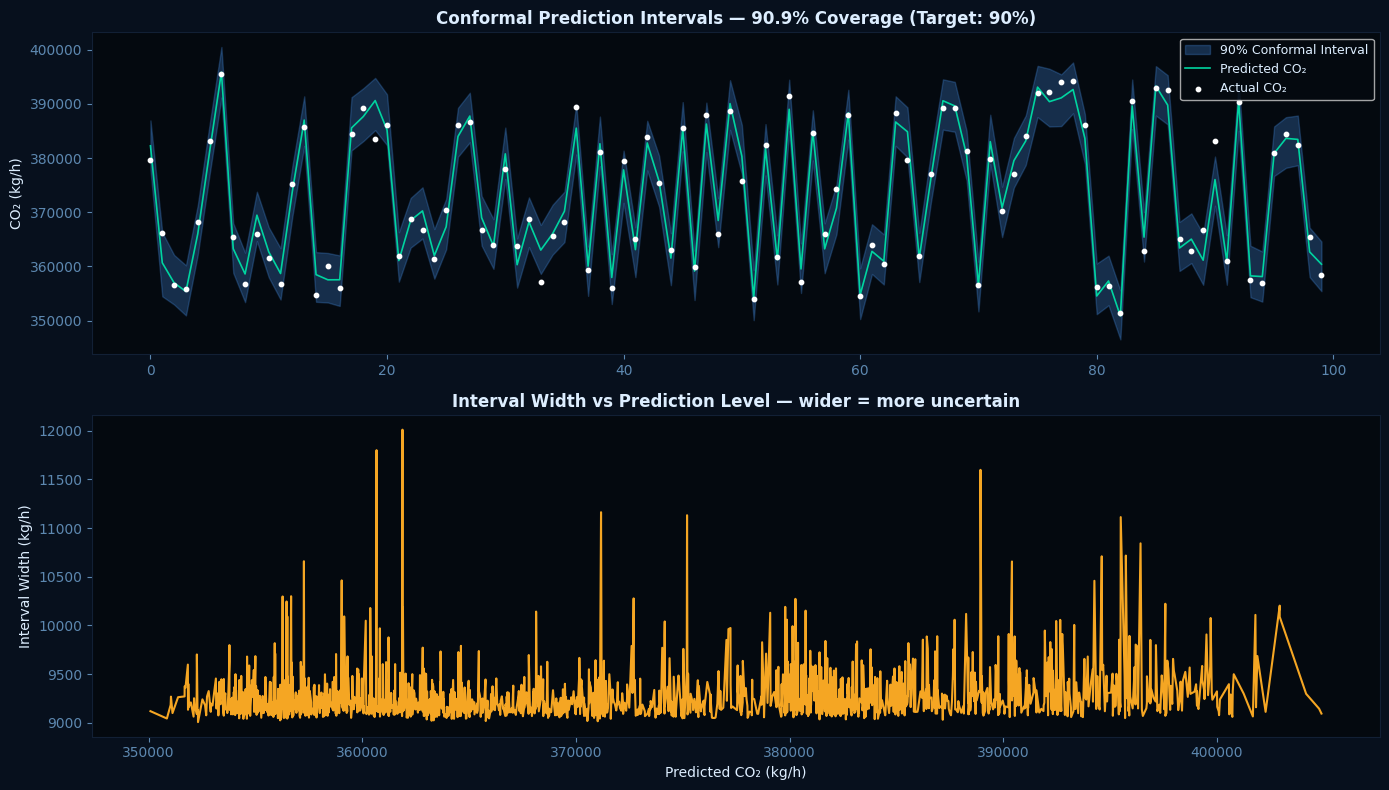

✅ Saved: models/conformal_mapie.pkl


In [47]:

n_plot = 100
idx_plot = np.arange(n_plot)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top: Interval plot : Are predictions correct within uncertainity 
axes[0].fill_between(idx_plot, lower[:n_plot], upper[:n_plot],
                     alpha=0.25, color=PALETTE[1], label='90% Conformal Interval')
axes[0].plot(idx_plot, y_pred_mapie[:n_plot], color=PALETTE[0],
             linewidth=1.2, label='Predicted CO₂')
axes[0].scatter(idx_plot, y_test.values[:n_plot],
                color='white', s=10, zorder=5, label='Actual CO₂')
axes[0].set_ylabel('CO₂ (kg/h)')
axes[0].set_title(f'Conformal Prediction Intervals — {covered*100:.1f}% Coverage (Target: 90%)',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Bottom: Interval width across range: Where is the model less confident 
sort_idx = np.argsort(y_pred_mapie)
axes[1].plot(y_pred_mapie[sort_idx], (upper-lower)[sort_idx],
             color=PALETTE[2], linewidth=1.5)
axes[1].set_xlabel('Predicted CO₂ (kg/h)')
axes[1].set_ylabel('Interval Width (kg/h)')
axes[1].set_title('Interval Width vs Prediction Level — wider = more uncertain',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/15_conformal_intervals.png', dpi=150, bbox_inches='tight')
plt.show()
joblib.dump(mapie, 'models/conformal_mapie.pkl')
print('✅ Saved: models/conformal_mapie.pkl')

In [48]:
#DICE : Counterfactual Explanations :

import dice_ml
#Dice required combined dataframe along with the target 
df_dice= X_train.copy()
df_dice[target]=y_train.values

continuous_feats= features # All are numeric 

#Creating Dice object :
d= dice_ml.Data(
    dataframe= df_dice,
    continuous_features= continuous_feats,
    outcome_name= target
)

#Wrap our trained model 
m= dice_ml.Model(
    model= Best_model,
    backend='sklearn',
    model_type='regressor'
)
#Creating Dice_Explainer : Main engine 
dice_exp= dice_ml.Dice(d,m,
                      method='random')# Tries random changes 

In [49]:
#Now generating counterfactuals for high emission cases :

#Select worst cases :
high_emission_idx= y_test.nlargest(10).index
high_emission_X= X_test.loc[high_emission_idx].head(3)

#Set Target :
permitted_ranges = {
    'AT': [df_dice['AT'].min(), df_dice['AT'].max()],
    'V':  [df_dice['V'].min(),  df_dice['V'].max()],
    'AP': [df_dice['AP'].min(), df_dice['AP'].max()],
    'RH': [df_dice['RH'].min(), df_dice['RH'].max()],
    'AT_squared': [df_dice['AT_squared'].min(), df_dice['AT_squared'].max()],
    'AT_cubed': [df_dice['AT_cubed'].min(), df_dice['AT_cubed'].max()],
}
features_to_vary = [f for f in df_dice.columns if f != target]

current_pred= Best_model.predict(high_emission_X)[0]
target_max_co2= current_pred*0.95 # Reduction of CO2 by 5 percent

print(f'Current emission: {current_pred:.0f} kg/h')
print(f'Target (10% less): {target_max_co2:.0f} kg/h')

#DICE:
try:
    cf= dice_exp.generate_counterfactuals(
         query_instances=high_emission_X.head(1),
         total_CFs=5,
         desired_range=[0, target_max_co2],
         permitted_range=permitted_ranges,
         features_to_vary= features_to_vary,
         random_seed=42
        
    )
    cf.visualize_as_dataframe(show_only_changes=True)

    cf_df = cf.cf_examples_list[0].final_cfs_df
    print(cf_df)

except Exception as e:
    print({e})


Current emission: 401888 kg/h
Target (10% less): 381793 kg/h


100%|██████████| 1/1 [00:00<00:00,  3.07it/s]

Query instance (original outcome : 401888.0)


,AT,V,AP,RH,heat_index,AT_V_ratio,AP_deviation,cooling_eff,AT_squared,AT_cubed,...,AT_roll_std_50,AT_roll_mean_100,AT_roll_std_100,AT_roll_mean_200,AT_roll_std_200,AT_missing,V_missing,AP_missing,RH_missing,co2_kg
0,6.93,40.669998,1020.169983,71.160004,4.931388,0.170396,6.92,0.003548,48.024899,332.812561,...,0.067449,6.6949,0.15385,6.3931,0.342803,0,0,0,0,401888.0



Diverse Counterfactual set (new outcome: [0, np.float64(381793.1445185996)])


,AT,V,AP,RH,heat_index,AT_V_ratio,AP_deviation,cooling_eff,AT_squared,AT_cubed,...,AT_roll_std_50,AT_roll_mean_100,AT_roll_std_100,AT_roll_mean_200,AT_roll_std_200,AT_missing,V_missing,AP_missing,RH_missing,co2_kg
0,-,-,-,-,-,-,-,0.0004251983,-,-,...,-,-,-,-,-,-,-,-,-,-
1,-,-,-,-,-,-,-19.12,0.0006335915,-,-,...,-,-,-,-,-,-,-,-,-,-
2,-,-,-,-,-,-,-,0.0006939614,-,-,...,-,-,0.068720214,-,-,-,-,-,-,-
3,-,-,-,-,-,-,-,0.0004862754,-,-,...,0.026452543,-,-,-,-,-,-,-,-,-
4,-,-,-,-,-,-,-,0.0007438067,-,-,...,-,-,0.07201821,-,-,-,-,-,-,-


     AT      V       AP     RH  heat_index  AT_V_ratio  AP_deviation  \
0  6.93  40.67  1020.17  71.16    4.931388    0.170396          6.92   
1  6.93  40.67  1020.17  71.16    4.931388    0.170396        -19.12   
2  6.93  40.67  1020.17  71.16    4.931388    0.170396          6.92   
3  6.93  40.67  1020.17  71.16    4.931388    0.170396          6.92   
4  6.93  40.67  1020.17  71.16    4.931388    0.170396          6.92   

   cooling_eff  AT_squared    AT_cubed  ...  AT_roll_std_50  AT_roll_mean_100  \
0     0.000425     48.0249  332.812557  ...        0.067449            6.6949   
1     0.000634     48.0249  332.812557  ...        0.067449            6.6949   
2     0.000694     48.0249  332.812557  ...        0.067449            6.6949   
3     0.000486     48.0249  332.812557  ...        0.026453            6.6949   
4     0.000744     48.0249  332.812557  ...        0.067449            6.6949   

   AT_roll_std_100  AT_roll_mean_200  AT_roll_std_200  AT_missing  V_missing  \


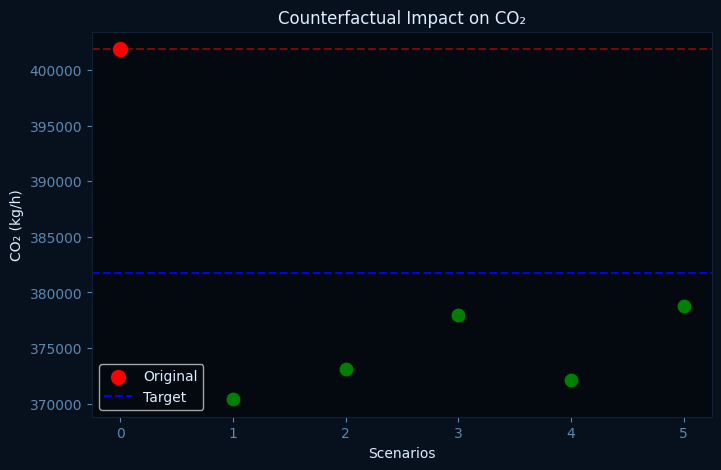

In [50]:
import matplotlib.pyplot as plt

query= X_test.loc[high_emission_idx].head(1).copy()

# Original instance
original = query.copy()
original_pred = Best_model.predict(original)[0]

# Counterfactuals
cf_df = cf.cf_examples_list[0].final_cfs_df

cf_preds = cf_df[target].values  # predicted values after change


plt.figure(figsize=(8,5))

plt.scatter([0], [original_pred], color='red', label='Original', s=100)

for i, val in enumerate(cf_preds):
    plt.scatter(i+1, val, color='green', s=80)

plt.axhline(original_pred, linestyle='--', color='red', alpha=0.5)
plt.axhline(target_max_co2, linestyle='--', color='blue', label='Target')

plt.title("Counterfactual Impact on CO₂")
plt.ylabel("CO₂ (kg/h)")
plt.xlabel("Scenarios")

plt.legend()
plt.savefig('outputs/plots/16_counterfactuals.png', dpi=150, bbox_inches='tight')
plt.show()

Week 6 : GREEN ML : Carbon Cost of Training 


In [51]:
#Tracking CO2 emitted during training of each model :
CANDIDATE_MODELS = [
    ('Ridge', ridge_pipe),
    ('ElasticNet', en_pipe),
    ('RandomForest', rf),
    ('XGBoost', xgb),
    ('XGB_Tuned', xgb_tuned),
    ('LightGBM', lgbm)
]

emissions_results = {}

for name, model in CANDIDATE_MODELS:
    tracker = EmissionsTracker(
        project_name=f'carbonsense_{name}',
        output_file='reports/emissions_log.csv',
        log_level='error'
    )
    
    tracker.start()
    model.fit(X_train, y_train)
    kg_co2 = tracker.stop()

    pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred))

    emissions_results[name] = {
        'rmse': rmse,
        'co2_g': kg_co2 * 1000
    }

    print(f'{name} → RMSE={rmse:.2f} | CO₂={kg_co2*1000:.4f} g')


Ridge → RMSE=3563.94 | CO₂=0.0001 g
ElasticNet → RMSE=3634.52 | CO₂=0.0005 g
RandomForest → RMSE=3076.88 | CO₂=0.0440 g
XGBoost → RMSE=3213.92 | CO₂=0.0091 g
XGB_Tuned → RMSE=3445.14 | CO₂=0.0244 g
LightGBM → RMSE=2973.83 | CO₂=0.0038 g


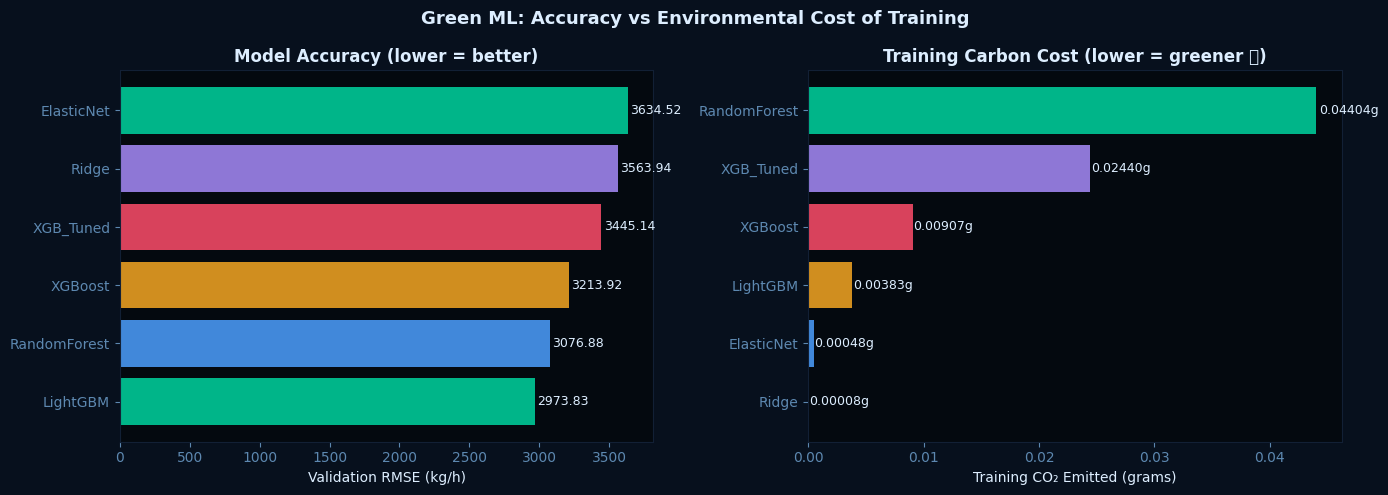

In [52]:
#Plot of carbon emission : 
em_df = pd.DataFrame(emissions_results).T.reset_index().rename(columns={'index':'Model'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE bars
em_sorted = em_df.sort_values('rmse')
axes[0].barh(em_sorted['Model'], em_sorted['rmse'],
             color=PALETTE[:len(em_df)], alpha=0.85)
axes[0].set_xlabel('Validation RMSE (kg/h)')
axes[0].set_title('Model Accuracy (lower = better)', fontweight='bold')
for i, (v, m) in enumerate(zip(em_sorted['rmse'], em_sorted['Model'])):
    axes[0].text(v * 1.005, i, f'{v:.2f}', va='center', fontsize=9)

# CO₂ of training bars
em_sorted2 = em_df.sort_values('co2_g')
axes[1].barh(em_sorted2['Model'], em_sorted2['co2_g'],
             color=PALETTE[:len(em_df)], alpha=0.85)
axes[1].set_xlabel('Training CO₂ Emitted (grams)')
axes[1].set_title('Training Carbon Cost (lower = greener 🌿)', fontweight='bold')
for i, v in enumerate(em_sorted2['co2_g']):
    axes[1].text(v * 1.005, i, f'{v:.5f}g', va='center', fontsize=9)

plt.suptitle('Green ML: Accuracy vs Environmental Cost of Training',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/17_green_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [53]:
# VERY IMPORTANT:
# Multi-objective Optuna

# Tuning best model while tracking CO2 emissions
# Finding trade-off between RMSE and CO2

moo_results = []

def multi_objective(trial):
    n_est = trial.suggest_int('n_estimators', 50, 600)
    depth = trial.suggest_int('max_depth', 2, 9)
    lr = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
    subsamp = trial.suggest_float('subsample', 0.5, 1.0)

    tracker = EmissionsTracker(log_level='error')
    tracker.start()

    model = LGBMRegressor(
        n_estimators=n_est,
        max_depth=depth,
        learning_rate=lr,
        subsample=subsamp,
        monotone_constraints=constraints_str,
        random_state=42,
        verbose=-1
    )

    model.fit(X_train, y_train)
    kg_co2 = tracker.stop()

    pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred))

    moo_results.append({
        'trial': trial.number,
        'rmse': rmse,
        'co2_g': kg_co2 * 1000,
        'n_est': n_est,
        'depth': depth
    })

    return rmse, kg_co2 * 1000  # minimize both



moo_study = optuna.create_study(
    directions=['minimize', 'minimize'],
    study_name='carbonssense_MOO'
)

moo_study.optimize(multi_objective, n_trials=30, show_progress_bar=True)

print('Multi-objective optimisation complete')

  0%|          | 0/30 [00:00<?, ?it/s]

Multi-objective optimisation complete


In [56]:

for t in moo_study.best_trials:
    rmse = t.values[0]
    co2 = t.values[1]

    print(f"Trial {t.number} → RMSE={rmse:.2f}, CO₂={co2:.2f} g")
    print(f"Params: {t.params}\n")

Trial 3 → RMSE=3237.46, CO₂=0.00 g
Params: {'n_estimators': 148, 'max_depth': 6, 'learning_rate': 0.1951133128406175, 'subsample': 0.5840377454841619}

Trial 7 → RMSE=3473.63, CO₂=0.00 g
Params: {'n_estimators': 69, 'max_depth': 2, 'learning_rate': 0.07764739717280132, 'subsample': 0.712294063234403}

Trial 9 → RMSE=3239.36, CO₂=0.00 g
Params: {'n_estimators': 145, 'max_depth': 5, 'learning_rate': 0.10393204589070776, 'subsample': 0.684581971730003}

Trial 11 → RMSE=3210.30, CO₂=0.00 g
Params: {'n_estimators': 255, 'max_depth': 9, 'learning_rate': 0.05798093128762114, 'subsample': 0.9367290014829279}

Trial 18 → RMSE=3222.22, CO₂=0.00 g
Params: {'n_estimators': 148, 'max_depth': 6, 'learning_rate': 0.05405751276523904, 'subsample': 0.9150125037946839}

Trial 23 → RMSE=3339.57, CO₂=0.00 g
Params: {'n_estimators': 244, 'max_depth': 2, 'learning_rate': 0.10319168592259295, 'subsample': 0.6115353032813108}

Trial 24 → RMSE=3270.19, CO₂=0.00 g
Params: {'n_estimators': 267, 'max_depth': 3, '

In [59]:
# DECISION SCIENCE:
# How much extra CO2 do I pay to gain a small improvement in accuracy?

moo_df = pd.DataFrame(moo_results)

# Best possible accuracy
best_rmse = moo_df['rmse'].min()

# Model with minimum CO2 emission
greenest = moo_df.loc[moo_df['co2_g'].idxmin()]

# Most accurate model (lowest RMSE)
most_acc = moo_df.loc[moo_df['rmse'].idxmin()]

# Accuracy gain (how much better the best model is)
delta_rmse = greenest['rmse'] - most_acc['rmse']

# Extra carbon cost to achieve that gain
delta_co2 = most_acc['co2_g'] - greenest['co2_g']

print(f'Greenest model  — RMSE: {greenest["rmse"]:.2f} kg/h | CO₂: {greenest["co2_g"]:.5f}g')
print(f'Most accurate   — RMSE: {most_acc["rmse"]:.2f} kg/h | CO₂: {most_acc["co2_g"]:.5f}g')

print(f'\nAccuracy gain:   {delta_rmse:.2f} kg/h better RMSE')
print(f'Carbon cost:     {delta_co2:.5f}g extra CO₂')

# CO2 per unit RMSE improvement
if delta_rmse > 0:
    print(f'Cost per 1 kg/h RMSE gain: {delta_co2/delta_rmse:.6f} g CO₂')
    print('\nConclusion: Accuracy gain achieved at this carbon cost.')
else:
    print('\nNo accuracy gain from switching models.')

Greenest model  — RMSE: 3473.63 kg/h | CO₂: 0.00051g
Most accurate   — RMSE: 3210.30 kg/h | CO₂: 0.00311g

Accuracy gain:   263.33 kg/h better RMSE
Carbon cost:     0.00260g extra CO₂
Cost per 1 kg/h RMSE gain: 0.000010 g CO₂

Conclusion: Accuracy gain achieved at this carbon cost.


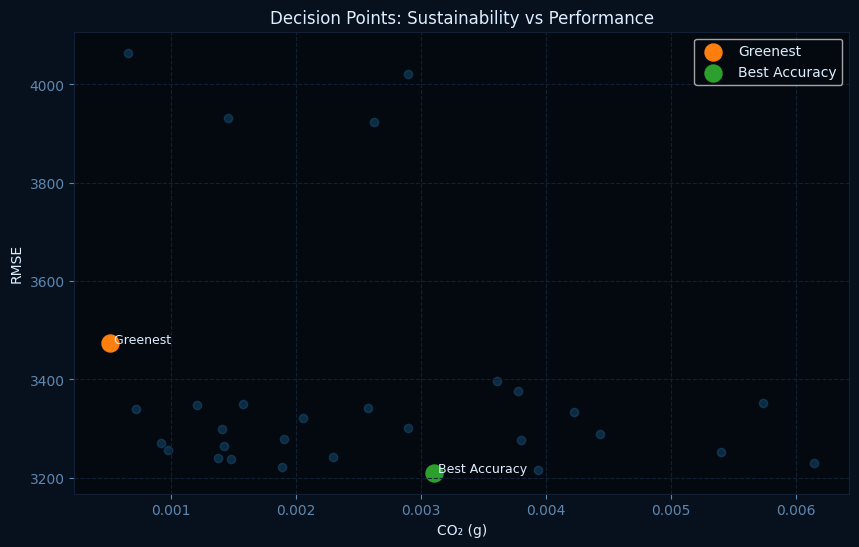

In [60]:
#Green AI :
plt.figure(figsize=(10, 6))

plt.scatter(moo_df['co2_g'], moo_df['rmse'], alpha=0.3)

plt.scatter(greenest['co2_g'], greenest['rmse'], s=150, label='Greenest')
plt.scatter(most_acc['co2_g'], most_acc['rmse'], s=150, label='Best Accuracy')

plt.text(greenest['co2_g'], greenest['rmse'], ' Greenest', fontsize=9)
plt.text(most_acc['co2_g'], most_acc['rmse'], ' Best Accuracy', fontsize=9)

plt.xlabel('CO₂ (g)')
plt.ylabel('RMSE')
plt.title('Decision Points: Sustainability vs Performance')

plt.legend()
plt.grid(True)
plt.show()

Week 7 : Clustering + Concept Drift Detection 


In [61]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

CLUSTER_FEATS = ['AT', 'V', 'AP', 'RH']
X_cluster_raw = df_ml[CLUSTER_FEATS].copy()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(X_cluster_raw)



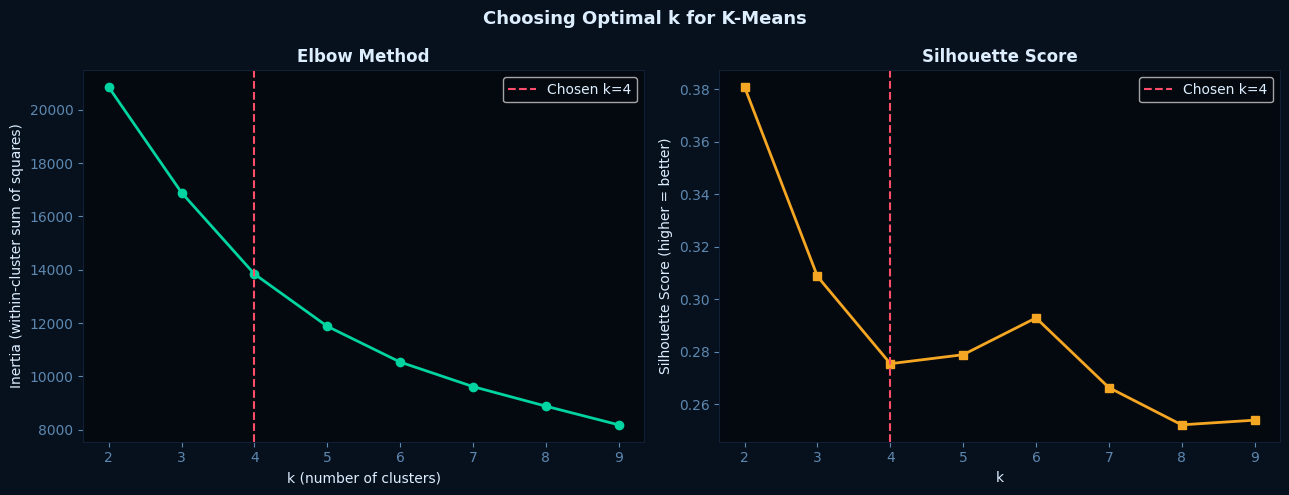

In [63]:
#For K means Elbow method to choose optimal value of K :
inertias    = []
sil_scores  = []
k_range     = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, labels, sample_size=2000))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range, inertias, marker='o', color=PALETTE[0], linewidth=2)
axes[0].axvline(4, color=PALETTE[3], linestyle='--', label='Chosen k=4')
axes[0].set_xlabel('k (number of clusters)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker='s', color=PALETTE[2], linewidth=2)
axes[1].axvline(4, color=PALETTE[3], linestyle='--', label='Chosen k=4')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].legend()

plt.suptitle('Choosing Optimal k for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/19_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

#Elbow suggest K=4


In [66]:
# K-Means Clustering
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=15)
cluster_labels = kmeans.fit_predict(X_cluster)

df_ml['cluster_km'] = cluster_labels

# Analysis of Cluster Profile
cluster_profile = df_ml.groupby('cluster_km')[CLUSTER_FEATS + ['co2_kg']].mean().round(2)

cluster_names = {}

for c in range(K):
    at_val = cluster_profile.loc[c, 'AT']   # ✅ fixed name

    if at_val < 10:
        cluster_names[c] = f'C{c}: Cold/Winter Mode'
    elif at_val < 18:
        cluster_names[c] = f'C{c}: Mild/Spring Mode'
    elif at_val < 26:
        cluster_names[c] = f'C{c}: Warm/Summer Mode'
    else:
        cluster_names[c] = f'C{c}: Hot/Peak Mode'

# Replace numeric Cluster IDs with readable names
cluster_profile.index = [cluster_names[i] for i in cluster_profile.index]

print(cluster_profile)

# Cluster quality metrics
sil = silhouette_score(X_cluster, cluster_labels)
db = davies_bouldin_score(X_cluster, cluster_labels)

print(f'\nSilhouette Score: {sil:.3f} (0–1, higher=better)')
print(f'Davies-Bouldin:   {db:.3f} (lower=better)')

#Here it is weak cluster : Overlapping 

                         AT      V       AP     RH     co2_kg
C0: Hot/Peak Mode     27.58  63.91  1010.86  54.95  360639.24
C1: Mild/Spring Mode  12.06  42.62  1020.20  77.65  386893.96
C2: Warm/Summer Mode  23.70  65.66  1011.07  79.33  362269.21
C3: Mild/Spring Mode  14.63  43.25  1010.00  82.50  381767.61

Silhouette Score: 0.277 (0–1, higher=better)
Davies-Bouldin:   1.269 (lower=better)


In [69]:
#Changing from K Means to Gaussian Mixture Model :
#It gives probabilities of belonging to each cluster :
#Point → 70% Cluster 2, 20% Cluster 1, 10% Cluster 3

gmm = GaussianMixture(n_components= K,random_state=42,n_init=5)
gmm.fit(X_cluster)
gmm_labels= gmm.predict(X_cluster)
gmm_probs= gmm.predict_proba(X_cluster)

df_ml['cluster_gmm']       = gmm_labels
df_ml['gmm_max_prob']      = gmm_probs.max(axis=1)  # confidence of cluster assignment

print(f'GMM Silhouette: {silhouette_score(X_cluster, gmm_labels):.3f}')
print(f'GMM average cluster confidence: {gmm_probs.max(axis=1).mean()*100:.3f}')


GMM Silhouette: 0.253
GMM average cluster confidence: 87.742


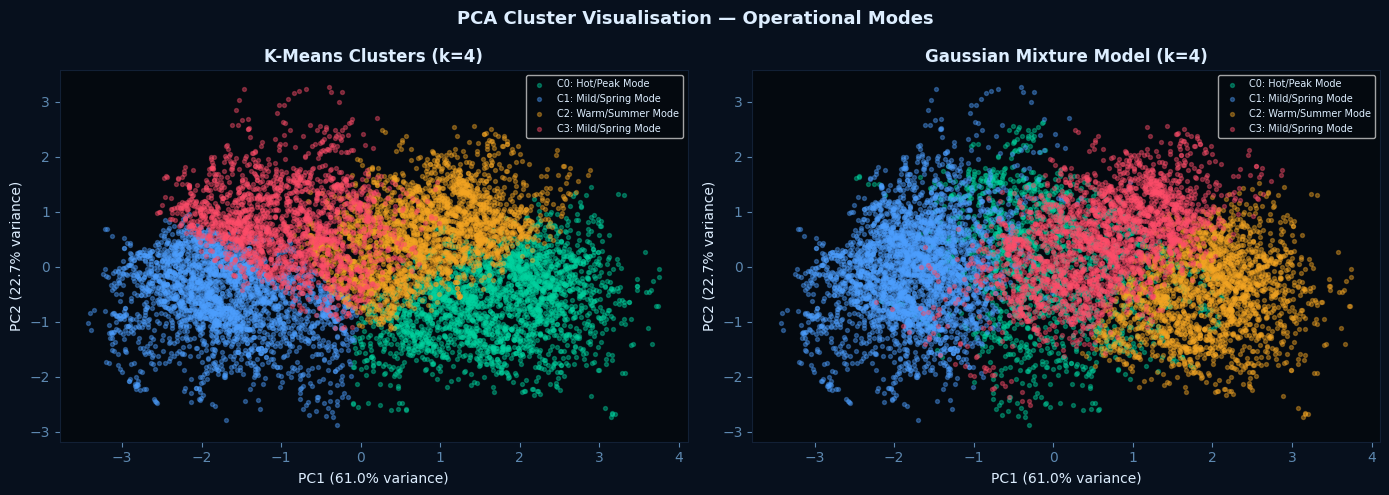

In [70]:
#PCA Visulaization of clusters :
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, labels, title in [
    (axes[0], cluster_labels, 'K-Means Clusters (k=4)'),
    (axes[1], gmm_labels,     'Gaussian Mixture Model (k=4)')
]:
    for c in range(K):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   label=list(cluster_names.values())[c],
                   color=PALETTE[c], alpha=0.4, s=8)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')

plt.suptitle('PCA Cluster Visualisation — Operational Modes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/20_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
#MOST IMPORTANT DETECTION :
#ADWIN : Concept Drift Detection 
#Relationship your model learned changes over time 

#You trained on 'old reality ' but world moves on 

#Workflow :
# Simulate drift: split dataset into two "time periods"
# Period 1 (summer-like): hot temperatures
# Period 2 (winter-like): cold temperatures
# Train on summer → test on winter → model degrades → ADWIN detects it

from river.drift import ADWIN 

df_sorted_at= df_ml.sort_values('AT').reset_index(drop=True)
n_half= len(df_sorted)//2

df_summer= df_sorted_at.tail(n_half).reset_index(drop=True)
df_winter= df_sorted_at.head(n_half).reset_index(drop=True)

X_summer= df_summer[features]
y_summer= df_summer[target]
X_winter= df_winter[features]
y_winter= df_winter[target]

summer_model = XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    tree_method='hist', random_state=42, verbosity=0)
summer_model.fit(X_summer, y_summer)

summer_rmse = np.sqrt(mean_squared_error(y_summer, summer_model.predict(X_summer)))
winter_rmse = np.sqrt(mean_squared_error(y_winter, summer_model.predict(X_winter)))
print(f'Summer model on SUMMER data: RMSE = {summer_rmse:.2f} kg/h')
print(f'Summer model on WINTER data: RMSE = {winter_rmse:.2f} kg/h')
print(f'Drift impact: +{winter_rmse - summer_rmse:.2f} kg/h RMSE degradation')

Summer model on SUMMER data: RMSE = 1465.50 kg/h
Summer model on WINTER data: RMSE = 12772.71 kg/h
Drift impact: +11307.22 kg/h RMSE degradation


In [73]:
#ADWIN drift detection on residual stream data :
detector     = ADWIN(delta=0.002)
drift_points = []

X_stream = pd.concat([X_summer, X_winter], ignore_index=True)
y_stream = pd.concat([y_summer, y_winter], ignore_index=True)

residuals_stream =[]

for i in range(len(X_stream)):
     pred     = summer_model.predict(X_stream.iloc[[i]])[0]
     #Used only summer model to detect drift if present 
     residual = abs(y_stream.iloc[i] - pred)
     residuals_stream.append(residual)

     detector.update(residual)
     if detector.drift_detected:
        drift_points.append(i)
        detector = ADWIN(delta=0.002)  # reset after detection

print(f'ADWIN detected drift at {len(drift_points)} points')
print(f'First detection at index: {drift_points[0] if drift_points else "None"}')



ADWIN detected drift at 10 points
First detection at index: 3231


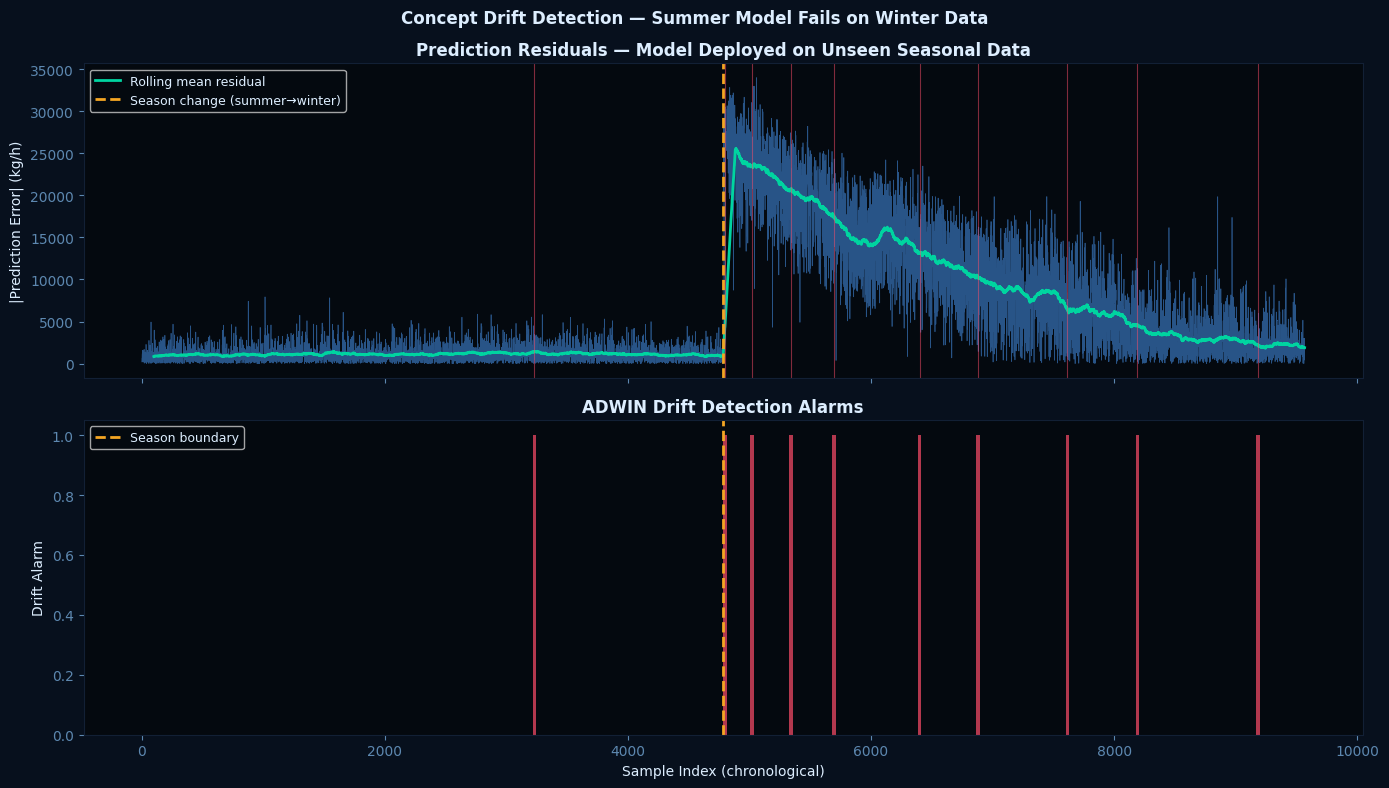

Production insight: Drift alarms cluster AFTER the seasonal boundary
→ Trigger: retrain model with fresh data when alarm rate exceeds threshold


In [74]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Residuals over time
axes[0].plot(residuals_stream, color=PALETTE[1], alpha=0.5, linewidth=0.5)
roll_res = pd.Series(residuals_stream).rolling(100).mean()
axes[0].plot(roll_res, color=PALETTE[0], linewidth=2, label='Rolling mean residual')
axes[0].axvline(n_half, color=PALETTE[2], linestyle='--',
                linewidth=2, label='Season change (summer→winter)')
for dp in drift_points[:10]:  # show first 10
    axes[0].axvline(dp, color=PALETTE[3], alpha=0.5, linewidth=0.8)
axes[0].set_ylabel('|Prediction Error| (kg/h)')
axes[0].set_title('Prediction Residuals — Model Deployed on Unseen Seasonal Data',
                  fontweight='bold')
axes[0].legend(fontsize=9)

# Drift alarms
axes[1].bar(drift_points, [1]*len(drift_points), width=30,
            color=PALETTE[3], alpha=0.7)
axes[1].axvline(n_half, color=PALETTE[2], linestyle='--',
                linewidth=2, label='Season boundary')
axes[1].set_ylabel('Drift Alarm')
axes[1].set_xlabel('Sample Index (chronological)')
axes[1].set_title('ADWIN Drift Detection Alarms', fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Concept Drift Detection — Summer Model Fails on Winter Data',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/22_drift_detection.png', dpi=150, bbox_inches='tight')
plt.show()
print('Production insight: Drift alarms cluster AFTER the seasonal boundary')
print('→ Trigger: retrain model with fresh data when alarm rate exceeds threshold')

In [ ]:
#This drift is 100% beacuse we train our model on olny summer data and test it on winter data 
#Season changes-> Model becomes old and outdated 
#hence need of drift_adaptation 

In [76]:
#VERY IMPORTANT USE :
#Evidently AI : Used to generate visual HTML Report 

!pip install evidently
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset

    # Build report comparing summer vs winter data distributions
    drift_report = Report(metrics=[DataDriftPreset()])
    drift_report.run(
        reference_data=df_summer[CLUSTER_FEATS].head(1000),
        current_data=df_winter[CLUSTER_FEATS].head(1000)
    )
    drift_report.save_html('reports/evidently_drift_report.html')
    print(' Evidently drift report saved: reports/evidently_drift_report.html')
    print('   Open this HTML file in your browser !!!')

except ImportError:
    print('Install evidently: pip install evidently')
except Exception as e:
    print( {e})


Install evidently: pip install evidently


In [77]:
joblib.dump(kmeans,       'models/kmeans_k4.pkl')
joblib.dump(gmm,          'models/gmm_k4.pkl')
joblib.dump(scaler,       'models/cluster_scaler.pkl')
joblib.dump(pca,          'models/pca_2d.pkl')
joblib.dump(summer_model, 'models/summer_baseline.pkl')
df_ml.to_parquet('data/processed/final_dataset_with_clusters.parquet', index=False)

                        THANK YOU !!!
                        